Estimated TLS Slope (m): -2.1765
Estimated TLS Intercept (c): 160.4191


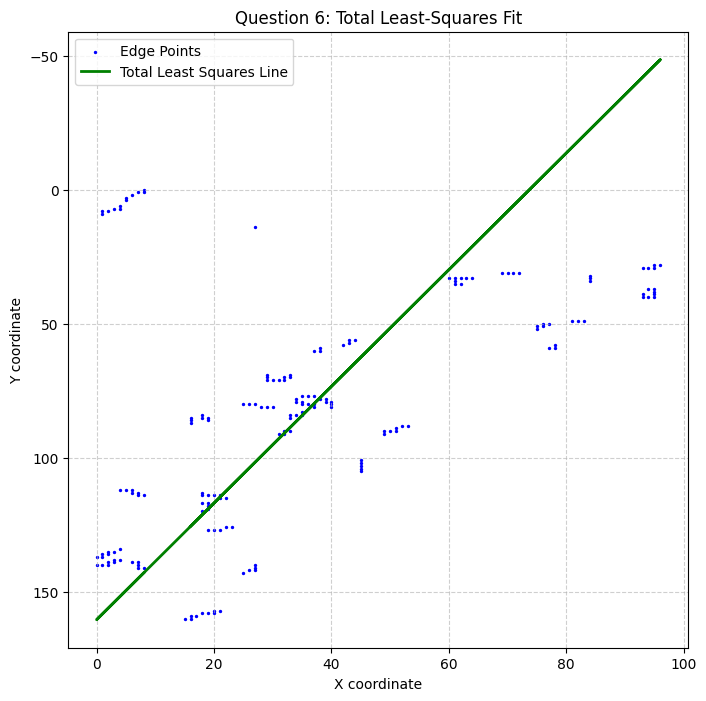

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


image_filename = 'IMages/1c.jpg'
img = cv.imread(image_filename, cv.IMREAD_GRAYSCALE)

if img is None:
    print(f"Error: Could not find {image_filename}. Check your folder path!")
else:
    # Apply Canny and get coordinates
    edges = cv.Canny(img, 550, 690)
    indices = np.where(edges != 0)
    x = indices[1]
    y = indices[0]

    # Total Least Squares (TLS) Fit using SVD
    # Calculate the mean of x and y
    x_mean = np.mean(x)
    y_mean = np.mean(y)

    # Mean-center the data points
    x_centered = x - x_mean
    y_centered = y - y_mean

    # Create the data matrix and compute Singular Value Decomposition
    Data = np.vstack((x_centered, y_centered)).T
    U, S, Vt = np.linalg.svd(Data)

    # The direction of the best fit line is the first principal component (first row of Vt)
    direction = Vt[0]
    
    # Calculate the new slope (m) and intercept (c)
    m_tls = direction[1] / direction[0]
    c_tls = y_mean - m_tls * x_mean

    print(f"Estimated TLS Slope (m): {m_tls:.4f}")
    print(f"Estimated TLS Intercept (c): {c_tls:.4f}")

    # Calculate the y values for the fitted line
    y_tls_fit = m_tls * x + c_tls

    # 3. Create the Scatter Plot with the TLS Fitted Line
    plt.figure(figsize=(8, 8))
    
    # Plot original edge points
    plt.scatter(x, y, s=2, c='blue', label='Edge Points') 
    
    # Plot the total least-squares line
    plt.plot(x, y_tls_fit, color='green', linewidth=2, label='Total Least Squares Line')

    # Invert the y-axis so the plot matches the orientation of the original image
    plt.gca().invert_yaxis() 

    plt.title('Question 6: Total Least-Squares Fit')
    plt.xlabel('X coordinate')
    plt.ylabel('Y coordinate')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6) 
    
    plt.show()